In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from collections import defaultdict
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
data_df = pd.read_csv("./data/1KG_sanders.trio_TRD_analysis.tsv", sep="\t")
for column in ["father", "mother", "child"]:
    data_df[column] = data_df[column].astype(str)
data_df["f-m"] = data_df["father"] + data_df["mother"]

In [3]:
# Filter total AF
data_df = data_df[(data_df["gnomad AF"] + data_df["ref AF"]) > 0.99]

# Filter informative records
mask1 = data_df.apply(
    lambda x: (x["gnomad AF"] < x["ref AF"])
    & (x["f-m"].count("1") == 1 and x["f-m"].count("0") == 3),
    axis=1,
)
mask2 = data_df.apply(
    lambda x: (x["ref AF"] < x["gnomad AF"])
    & (x["f-m"].count("1") == 3 and x["f-m"].count("0") == 1),
    axis=1,
)
mask = mask1 | mask2
data_df = data_df[mask].drop(columns=["f-m"])

# Determine if the variant is transmitted
data_df["is_transmit"] = data_df.apply(lambda x: x["child"] == '[0, 1]', axis=1)

# Process gene name
data_df["gene name"] = data_df["gene name"].apply(lambda x: ast.literal_eval(x))
data_df["gene name"] = data_df["gene name"].apply(lambda x: '|'.join(x))

In [4]:
# Calculate MAF
data_df["MAF"] = data_df[["gnomad AF", "ref AF"]].min(axis=1)

# Filter genes
data_df = data_df[
    (data_df["gene name"].str.startswith("H1-") == False) & (
        data_df["gene name"] != "H4C7"
    ) & (
        data_df["gene name"] != "H2BC1"
    )
]

In [5]:
# Simulation for null distribution of transmit ratio
plot_df_lst = defaultdict(list)

for dataset in data_df["dataset"].unique():

    # Set random seed
    np.random.seed(42)
    for value in [0.0001, 0.001, 0.01, 0.1, 0.5]:

        for mutation_type in ["nonsynonymous SNV", "synonymous SNV"]:

            sub_df = data_df[
                (data_df["dataset"] == dataset)
                & (data_df["MAF"] < value)
                & (data_df["consequence"] == mutation_type)
            ]

            transmit_count = 0
            untransmit_count = 0
            for site, df in sub_df.groupby("site"):
                tranmit_ratio = df["is_transmit"].sum() / df.shape[0]
                transmit_count += tranmit_ratio
                untransmit_count += 1 - tranmit_ratio

            site_counts = sub_df.groupby("site").size().values
            simulate_transmit_count_lst = [
                np.sum(np.random.binomial(site_counts, 0.5) / site_counts)
                for _ in range(1000)
            ]
            p_value = (
                1
                - np.sum(transmit_count < np.array(simulate_transmit_count_lst)) / 1000
            )

            plot_df_lst["transmit count"].append(transmit_count)
            plot_df_lst["untransmit count"].append(untransmit_count)
            plot_df_lst["transmit ratio"].append(
                transmit_count / (transmit_count + untransmit_count)
            )
            plot_df_lst["p value"].append(p_value)
            # Record simulation result (max and 95 low percentile)
            plot_df_lst["simu upper"].append(np.max(simulate_transmit_count_lst))
            plot_df_lst["simu lower"].append(
                np.percentile(simulate_transmit_count_lst, 5)
            )
            plot_df_lst["mutation type"].append(mutation_type)
            plot_df_lst["MAF"].append(value)
            plot_df_lst["unique site count"].append(sub_df["site"].nunique())
            plot_df_lst["dataset"].append(dataset)

plot_df = pd.DataFrame(plot_df_lst)

In [6]:
# Benjamini-Hochberg correction for multiple testing
plot_df['dataset source'] = plot_df['dataset'].apply(lambda x: x.split('_')[0])
plot_df['p value adj'] = plot_df.groupby('dataset source')['p value'].transform(lambda x: multipletests(x, method='fdr_bh')[1])

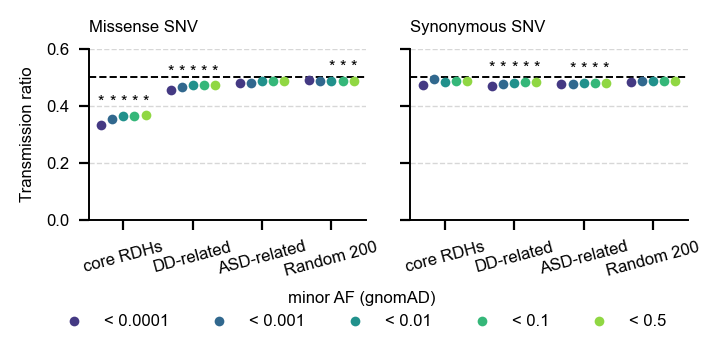

In [7]:
# Plot
label_map = {
    "RDH": "core RDHs",
    "ASD": "ASD-related",
    "DD": "DD-related",
    "R200": "Random 200",
}

AF_bin = [0.0001, 00.001, 0.01, 0.1, 0.5]

palette = sns.color_palette("viridis", n_colors=len(AF_bin))
fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.6), sharey=True)

mis_plot_df = plot_df[
    (plot_df["mutation type"] == "nonsynonymous SNV")
    & (plot_df["dataset"].str.startswith("1KG"))
]
mis_plot_df["dataset"] = mis_plot_df["dataset"].apply(
    lambda x: label_map[x.replace("1KG_", "")]
)

sns.swarmplot(
    data=mis_plot_df,
    x="dataset",
    y="transmit ratio",
    hue="MAF",
    hue_order=AF_bin,
    palette=palette,
    dodge=True,
    size=3.5,
    ax=axes[0],
)
axes[0].set_title(
    "Missense SNV",
    loc="left",
)

syn_plot_df = plot_df[
    (plot_df["mutation type"] == "synonymous SNV")
    & (plot_df["dataset"].str.startswith("1KG"))
]
syn_plot_df["dataset"] = syn_plot_df["dataset"].apply(
    lambda x: label_map[x.replace("1KG_", "")]
)
sns.swarmplot(
    data=syn_plot_df,
    x="dataset",
    y="transmit ratio",
    hue="MAF",
    hue_order=AF_bin,
    palette=palette,
    dodge=True,
    size=3.5,
    ax=axes[1],
)
axes[1].set_title(
    "Synonymous SNV",
    loc="left",
)

# Annotate P value
mis_plot_df["p label"] = mis_plot_df["p value adj"].apply(
    lambda x: "*" if x < 0.05 else ""
)
syn_plot_df["p label"] = syn_plot_df["p value adj"].apply(
    lambda x: "*" if x < 0.05 else ""
)
spacing = 0.8 / 5
for i, ax in enumerate(axes):
    plot_df_sub = mis_plot_df if i == 0 else syn_plot_df
    for j, dataset in enumerate(plot_df_sub["dataset"].unique()):
        sub_df = plot_df_sub[plot_df_sub["dataset"] == dataset]
        y = sub_df["transmit ratio"].max() + 0.02
        for idx, p_label in enumerate(sub_df["p label"].to_list()):
            x_pos = j - spacing * 2 + idx * spacing
            if p_label != "":
                ax.text(x_pos, y, p_label, ha="center", va="bottom")


# ----- shared legend (discrete, 5 AF values) -----
handles, labels = axes[0].get_legend_handles_labels()  # grab before removing
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(
    handles,
    [f"< {i}" for i in labels],
    title="minor AF (gnomAD)",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=len(AF_bin),
    frameon=False,
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.7)
    ax.set_ylim(0, 0.6)
    ax.set_xlabel("")
    # x axis rotation
    ax.xaxis.set_tick_params(rotation=15)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylabel("Transmission ratio")

plt.tight_layout(rect=[0, 0.08, 1, 1])